```markdown
# E-commerce Repeat Purchase Prediction Project

## Project Overview
This project focuses on developing a machine learning model to predict repeat purchases from e-commerce customer data. The goal is to identify customers who are likely to make future purchases, enabling businesses to tailor marketing strategies and improve customer retention.

The development process involved several key stages:
1.  **Data Loading and Initial Inspection**: Loading raw customer, order, product, payment, shipping, and discount data from CSV files into pandas DataFrames.
2.  **Data Merging and Preparation**: Consolidating relevant DataFrames (orders, customers, order_items, products) into a single comprehensive dataset. Date fields were converted to datetime objects for time-based analysis.
3.  **Target Variable Definition**: Defining 'repeat customers' as those who have placed more than one order.
4.  **Feature Engineering**: Creating customer-level features such as total spent, average order value, number of unique products purchased, total quantity purchased, and customer tenure (days since signup).
5.  **Initial Model Training and Evaluation**: Training a `RandomForestClassifier` and evaluating its performance, which initially revealed challenges with class imbalance.
6.  **Addressing Class Imbalance**: Employing the Synthetic Minority Over-sampling Technique (SMOTE) to balance the dataset, leading to improved recall for the minority class.
7.  **Hyperparameter Tuning**: Using `GridSearchCV` to optimize the `RandomForestClassifier`'s hyperparameters for better overall performance, specifically targeting the weighted F1-score.
8.  **Advanced Feature Engineering (RFM Analysis)**: Developing Recency, Frequency, and Monetary (RFM) features to capture more nuanced customer behavior.
9.  **Data Leakage Identification and Resolution**: Identifying and rectifying data leakage caused by directly using `num_orders` (which defines the target variable) as a feature, resulting in a more realistic model.
10. **Final Model Training and Evaluation**: Retraining the `RandomForestClassifier` with the refined RFM features (excluding the leaky feature) and evaluating its performance.
11. **Dashboard Generation**: Creating a simple dashboard to visualize key RFM metrics and the distribution of repeat customers.

## Technical Stack and Libraries

This project is implemented in Python and leverages several powerful libraries for data manipulation, machine learning, and visualization:

*   **Python**: The primary programming language.
*   **pandas**: Used extensively for data loading, cleaning, manipulation, and feature engineering. Its DataFrame structure is central to handling the tabular data.
*   **scikit-learn (`sklearn`)**: The core machine learning library, used for:
    *   `train_test_split`: For splitting data into training and testing sets.
    *   `RandomForestClassifier`: The chosen machine learning model for classification.
    *   `accuracy_score`, `classification_report`, `confusion_matrix`: For model evaluation metrics.
    *   `GridSearchCV`: For systematic hyperparameter tuning.
*   **imbalanced-learn (`imblearn`)**: A library specifically designed to deal with imbalanced datasets. `SMOTE` (Synthetic Minority Over-sampling Technique) was used to mitigate class imbalance.
*   **matplotlib**: A fundamental plotting library for creating static, interactive, and animated visualizations in Python.
*   **seaborn**: A high-level data visualization library based on matplotlib, providing a more aesthetic and user-friendly interface for drawing attractive statistical graphics.
*   **Counter (from `collections`)**: Used for easily counting hashable objects, particularly useful for understanding class distribution.

## Key Findings and Model Performance

The final model, trained on RFM features (excluding `num_orders` to prevent data leakage) and with SMOTE applied, achieved a balanced performance:
*   **Accuracy**: Approximately 0.89
*   **Recall (for non-repeat customers)**: Improved significantly to 0.82
*   **F1-score (for non-repeat customers)**: 0.75

Feature importance analysis revealed that `avg_order_value`, `total_spent`, and `num_unique_products` were the most influential features in predicting repeat purchases.

## Conclusion
This project successfully developed a machine learning model capable of predicting e-commerce repeat purchases. By carefully handling data merging, feature engineering, and class imbalance, a robust model was created that provides actionable insights into customer behavior. The generated dashboard further aids in understanding the characteristics of repeat versus non-repeat customers.
```

## E-commerce Repeat Purchase Project

This project aims to build an ML model to predict repeat purchases based on the provided e-commerce data. The process will involve:

1.  **Data Loading and Initial Inspection**: Load all CSV files into DataFrames and understand their structure.
2.  **Exploratory Data Analysis (EDA)**: Analyze distributions, relationships, and identify patterns.
3.  **Feature Engineering**: Create relevant features from the raw data for model training.
4.  **Target Variable Definition**: Define what constitutes a 'repeat purchase'.
5.  **Model Training**: Select and train a suitable machine learning model.
6.  **Model Evaluation**: Assess the model's performance.

In [1]:
import pandas as pd

# List of CSV files provided
csv_files = [
    'customers.csv',
    'orders.csv',
    'order_items.csv',
    'products.csv',
    'payments.csv',
    'shipping.csv',
    'discounts.csv'
]

# Dictionary to store DataFrames
dfs = {}

# Load each CSV file into a DataFrame and store in the dictionary
for file in csv_files:
    df_name = file.replace('.csv', '')  # Use filename without extension as DataFrame name
    try:
        dfs[df_name] = pd.read_csv(f'/content/{file}')
        print(f"Successfully loaded {file} into df['{df_name}']")
    except Exception as e:
        print(f"Error loading {file}: {e}")


Successfully loaded customers.csv into df['customers']
Successfully loaded orders.csv into df['orders']
Successfully loaded order_items.csv into df['order_items']
Successfully loaded products.csv into df['products']
Successfully loaded payments.csv into df['payments']
Successfully loaded shipping.csv into df['shipping']
Successfully loaded discounts.csv into df['discounts']


### Initial Data Inspection

Let's display the first few rows and general information for each loaded DataFrame to get an overview of the data.

In [2]:
for df_name, df in dfs.items():
    print(f"\n--- DataFrame: {df_name} ---")
    print("Head:")
    display(df.head())
    print("Info:")
    df.info()
    print("Describe:")
    display(df.describe(include='all'))



--- DataFrame: customers ---
Head:


,customer_id,country,signup_date
0,CUST1,Canada,2023-08-10
1,CUST2,UAE,2023-06-15
2,CUST3,UK,2024-06-11
3,CUST4,UAE,2023-07-13
4,CUST5,UAE,2024-02-11


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   customer_id  300 non-null    object
 1   country      300 non-null    object
 2   signup_date  300 non-null    object
dtypes: object(3)
memory usage: 7.2+ KB
Describe:


,customer_id,country,signup_date
count,300,300,300
unique,300,6,230
top,CUST300,Canada,2023-06-18
freq,1,64,4



--- DataFrame: orders ---
Head:


...

,order_id,delivery_days,shipping_region
count,900,900.000000,900
unique,900,NaN,4
top,ORD900,NaN,East
freq,1,NaN,234
mean,NaN,4.957778,NaN
std,NaN,2.592107,NaN
min,NaN,1.000000,NaN
25%,NaN,3.000000,NaN
50%,NaN,5.000000,NaN
75%,NaN,7.000000,NaN



--- DataFrame: discounts ---
Head:


,order_id,discount_percent
0,ORD1,20
1,ORD2,20
2,ORD3,5
3,ORD4,0
4,ORD5,0


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   order_id          900 non-null    object
 1   discount_percent  900 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 14.2+ KB
Describe:


,order_id,discount_percent
count,900,900.000000
unique,900,NaN
top,ORD900,NaN
freq,1,NaN
mean,NaN,9.705556
std,NaN,6.967825
min,NaN,0.000000
25%,NaN,5.000000
50%,NaN,10.000000
75%,NaN,15.000000


### Data Merging and Preparation

To build a model for repeat purchases, we need to consolidate information from various tables. We'll start by merging `orders` with `customers`, then add `order_items` and `products` to create a comprehensive transactional dataset.

In [3]:
# Convert signup_date and order_date to datetime objects
dfs['customers']['signup_date'] = pd.to_datetime(dfs['customers']['signup_date'])
dfs['orders']['order_date'] = pd.to_datetime(dfs['orders']['order_date'])

# Merge orders and customers
merged_df = pd.merge(dfs['orders'], dfs['customers'], on='customer_id', how='left')

# Merge with order_items
merged_df = pd.merge(merged_df, dfs['order_items'], on='order_id', how='left')

# Merge with products
merged_df = pd.merge(merged_df, dfs['products'], on='product_id', how='left')

print("Merged DataFrame head:")
display(merged_df.head())

print("Merged DataFrame info:")
merged_df.info()


Merged DataFrame head:


,order_id,customer_id,order_date,discount_used,country,signup_date,product_id,quantity,category,price
0,ORD1,CUST104,2024-09-19,0,India,2023-03-29,NaN,NaN,NaN,NaN
1,ORD2,CUST299,2024-08-31,1,Australia,2024-04-19,PROD15,2.0,Electronics,242.0
2,ORD3,CUST246,2024-04-18,0,UK,2024-07-30,PROD20,1.0,Books,108.0
3,ORD4,CUST176,2024-05-27,1,USA,2024-07-02,NaN,NaN,NaN,NaN
4,ORD5,CUST39,2024-02-26,1,Canada,2023-03-13,NaN,NaN,NaN,NaN


Merged DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1256 entries, 0 to 1255
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       1256 non-null   object        
 1   customer_id    1256 non-null   object        
 2   order_date     1256 non-null   datetime64[ns]
 3   discount_used  1256 non-null   int64         
 4   country        1256 non-null   object        
 5   signup_date    1256 non-null   datetime64[ns]
 6   product_id     900 non-null    object        
 7   quantity       900 non-null    float64       
 8   category       900 non-null    object        
 9   price          900 non-null    float64       
dtypes: datetime64[ns](2), float64(2), int64(1), object(5)
memory usage: 98.3+ KB


### Defining Repeat Purchase Target Variable

For a repeat purchase model, we need to define what constitutes a 'repeat customer'. A common approach is to identify customers who have made more than one order. We will create a `repeat_customer` target variable based on this definition.

In [4]:
# Calculate the number of orders per customer
orders_per_customer = merged_df.groupby('customer_id')['order_id'].nunique().reset_index()
orders_per_customer.rename(columns={'order_id': 'total_orders'}, inplace=True)

# Define repeat customer: more than one order
orders_per_customer['is_repeat_customer'] = (orders_per_customer['total_orders'] > 1).astype(int)

# Display the count of repeat customers
print("Repeat customer distribution:")
display(orders_per_customer['is_repeat_customer'].value_counts())

# Merge this back to the main dataframe (or use it separately for customer-level prediction)
# For now, let's keep it as a separate dataframe for customer-level analysis.
# We will eventually need to decide if we're predicting repeat purchase on a per-order basis or per-customer basis.
# For a first pass, let's focus on customer-level prediction (is this customer a repeat customer?)


Repeat customer distribution:


,count
is_repeat_customer,
1,231
0,53


### Feature Engineering (Customer-Level)

Let's create several customer-level features from our `merged_df` to capture purchasing behavior, value, and product preferences. These will include:
- Total amount spent per customer.
- Average order value per customer.
- Number of unique products purchased by customer.
- Total quantity of items purchased per customer.
- Recency (days since last purchase).
- Frequency (total number of orders, which we already have).
- Customer tenure (days since signup).

In [5]:
# Calculate item total price
merged_df['item_total_price'] = merged_df['price'] * merged_df['quantity']

# Aggregate features at customer level
customer_features = merged_df.groupby('customer_id').agg(
    total_spent=('item_total_price', 'sum'),
    avg_order_value=('item_total_price', 'mean'), # This is average item price, not avg order value yet
    num_unique_products=('product_id', 'nunique'),
    total_quantity_purchased=('quantity', 'sum'),
    last_order_date=('order_date', 'max')
).reset_index()

# Calculate customer tenure (days since signup)
# First, merge signup_date from the customers dataframe
customer_features = pd.merge(customer_features, dfs['customers'][['customer_id', 'signup_date']], on='customer_id', how='left')
customer_features['customer_tenure_days'] = (customer_features['last_order_date'] - customer_features['signup_date']).dt.days

# Merge with repeat customer flag
customer_features = pd.merge(customer_features, orders_per_customer[['customer_id', 'is_repeat_customer']], on='customer_id', how='left')

# Display the new customer features dataframe
print("Customer Features DataFrame head:")
display(customer_features.head())

print("Customer Features DataFrame info:")
customer_features.info()


Customer Features DataFrame head:


,customer_id,total_spent,avg_order_value,num_unique_products,total_quantity_purchased,last_order_date,signup_date,customer_tenure_days,is_repeat_customer
0,CUST1,4104.0,684.00,5,17.0,2024-12-04,2023-08-10,482,1
1,CUST10,2278.0,569.50,4,12.0,2024-09-27,2023-01-31,605,1
2,CUST100,846.0,846.00,1,3.0,2024-12-15,2023-03-17,639,1
3,CUST101,1263.0,315.75,4,8.0,2024-08-25,2023-01-21,582,1
4,CUST102,0.0,NaN,0,0.0,2024-11-20,2023-06-08,531,0


Customer Features DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284 entries, 0 to 283
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   customer_id               284 non-null    object        
 1   total_spent               284 non-null    float64       
 2   avg_order_value           245 non-null    float64       
 3   num_unique_products       284 non-null    int64         
 4   total_quantity_purchased  284 non-null    float64       
 5   last_order_date           284 non-null    datetime64[ns]
 6   signup_date               284 non-null    datetime64[ns]
 7   customer_tenure_days      284 non-null    int64         
 8   is_repeat_customer        284 non-null    int64         
dtypes: datetime64[ns](2), float64(3), int64(3), object(1)
memory usage: 20.1+ KB


### Data Preprocessing

Before training a machine learning model, we need to preprocess the data. This often involves:
- Handling missing values (if any).
- Encoding categorical features (if any).
- Scaling numerical features.

Let's check for missing values and prepare our feature matrix (X) and target vector (y).

In [6]:
# Check for missing values
print("Missing values in customer_features:")
print(customer_features.isnull().sum())

# For now, let's drop rows with any missing values, though imputation might be better for real-world scenarios.
# In this synthetic dataset, missing values might indicate issues or specific patterns.
customer_features.dropna(inplace=True)

# Define features (X) and target (y)
X = customer_features[['total_spent', 'avg_order_value', 'num_unique_products', 'total_quantity_purchased', 'customer_tenure_days']]
y = customer_features['is_repeat_customer']

# Display the shape of X and y
print(f"\nShape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

# Display a sample of X and y
print("\nSample of X:")
display(X.head())
print("\nSample of y:")
display(y.head())


Missing values in customer_features:
customer_id                  0
total_spent                  0
avg_order_value             39
num_unique_products          0
total_quantity_purchased     0
last_order_date              0
signup_date                  0
customer_tenure_days         0
is_repeat_customer           0
dtype: int64

Shape of X: (245, 5)
Shape of y: (245,)

Sample of X:


,total_spent,avg_order_value,num_unique_products,total_quantity_purchased,customer_tenure_days
0,4104.0,684.00,5,17.0,482
1,2278.0,569.50,4,12.0,605
2,846.0,846.00,1,3.0,639
3,1263.0,315.75,4,8.0,582
6,1345.0,269.00,4,11.0,621



Sample of y:


,is_repeat_customer
0,1
1,1
2,1
3,1
6,1


### Model Training

We will now train a classification model to predict `is_repeat_customer`. We'll use a `RandomForestClassifier` as it's a robust and widely used algorithm. First, we need to split our data into training and testing sets.

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

# Initialize and train the RandomForestClassifier
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

print("\nRandomForestClassifier trained successfully.")


Shape of X_train: (196, 5)
Shape of X_test: (49, 5)
Shape of y_train: (196,)
Shape of y_test: (49,)

RandomForestClassifier trained successfully.


### Model Evaluation

Let's evaluate the performance of our trained model on the test set using common classification metrics like accuracy, precision, recall, F1-score, and the confusion matrix.

In [8]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
print("\nModel Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Display feature importances
print("\nFeature Importances:")
feature_importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
display(feature_importances)



Model Evaluation:
Accuracy: 0.8980

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.29      0.44         7
           1       0.89      1.00      0.94        42

    accuracy                           0.90        49
   macro avg       0.95      0.64      0.69        49
weighted avg       0.91      0.90      0.87        49


Confusion Matrix:
[[ 2  5]
 [ 0 42]]

Feature Importances:


,0
avg_order_value,0.286156
customer_tenure_days,0.262752
total_spent,0.255346
total_quantity_purchased,0.118068
num_unique_products,0.077677


### Conclusion and Next Steps

The model has been trained and evaluated. The next steps could involve:
- **Hyperparameter Tuning**: Optimize the model's parameters for better performance.
- **More Feature Engineering**: Explore additional features from existing data or external sources.
- **Different Models**: Experiment with other classification algorithms.
- **Interpretation**: Deep dive into why certain features are important and what they imply about repeat customer behavior.
- **Deployment**: If performance is satisfactory, prepare the model for deployment.

### Next Step 1: Addressing Class Imbalance with SMOTE

As observed from the evaluation, our model struggles with the minority class (non-repeat customers), likely due to the imbalanced dataset. We will use Synthetic Minority Over-sampling Technique (SMOTE) to oversample the minority class in the training data, creating a more balanced dataset for the model to learn from.

In [9]:
from imblearn.over_sampling import SMOTE
from collections import Counter

print(f"Original training set shape: {Counter(y_train)}")

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)

print(f"Resampled training set shape: {Counter(y_res)}")

# Now, train the model with the resampled data
model_resampled = RandomForestClassifier(random_state=42)
model_resampled.fit(X_res, y_res)

# Evaluate the resampled model
y_pred_resampled = model_resampled.predict(X_test)

print("\nModel Evaluation after SMOTE:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_resampled):.4f}")
print("\nClassification Report after SMOTE:")
print(classification_report(y_test, y_pred_resampled))
print("\nConfusion Matrix after SMOTE:")
print(confusion_matrix(y_test, y_pred_resampled))


Original training set shape: Counter({1: 170, 0: 26})
Resampled training set shape: Counter({1: 170, 0: 170})

Model Evaluation after SMOTE:
Accuracy: 0.8571

Classification Report after SMOTE:
              precision    recall  f1-score   support

           0       0.50      0.71      0.59         7
           1       0.95      0.88      0.91        42

    accuracy                           0.86        49
   macro avg       0.72      0.80      0.75        49
weighted avg       0.88      0.86      0.87        49


Confusion Matrix after SMOTE:
[[ 5  2]
 [ 5 37]]


### Next Step 2: Hyperparameter Tuning with GridSearchCV

Now that we've addressed the class imbalance, let's perform hyperparameter tuning on our `RandomForestClassifier` to find the optimal set of parameters. We'll use `GridSearchCV` to systematically search through a predefined set of hyperparameters and evaluate the model using cross-validation. Since our goal is to improve the detection of the minority class, we will optimize for 'f1_weighted' or 'recall' score.

In [10]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_features': ['sqrt', 'log2'],
    'max_depth': [4, 6, 8, 10],
    'criterion': ['gini', 'entropy']
}

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5, # 5-fold cross-validation
    scoring='f1_weighted', # Optimize for weighted F1-score given class imbalance
    n_jobs=-1, # Use all available cores
    verbose=1
)

# Fit GridSearchCV on the resampled training data
grid_search.fit(X_res, y_res)

print("\nBest parameters found:", grid_search.best_params_)
print("Best F1-weighted score:", grid_search.best_score_)

# Get the best model
best_model = grid_search.best_estimator_

# Evaluate the best model on the test set
y_pred_tuned = best_model.predict(X_test)

print("\nModel Evaluation after Hyperparameter Tuning:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_tuned):.4f}")
print("\nClassification Report after Hyperparameter Tuning:")
print(classification_report(y_test, y_pred_tuned))
print("\nConfusion Matrix after Hyperparameter Tuning:")
print(confusion_matrix(y_test, y_pred_tuned))

# Display feature importances of the best model
print("\nFeature Importances of the Best Model:")
feature_importances_tuned = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)
display(feature_importances_tuned)


Fitting 5 folds for each of 48 candidates, totalling 240 fits

Best parameters found: {'criterion': 'gini', 'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 100}
Best F1-weighted score: 0.8521472195620904

Model Evaluation after Hyperparameter Tuning:
Accuracy: 0.8571

Classification Report after Hyperparameter Tuning:
              precision    recall  f1-score   support

           0       0.50      0.71      0.59         7
           1       0.95      0.88      0.91        42

    accuracy                           0.86        49
   macro avg       0.72      0.80      0.75        49
weighted avg       0.88      0.86      0.87        49


Confusion Matrix after Hyperparameter Tuning:
[[ 5  2]
 [ 5 37]]

Feature Importances of the Best Model:


,0
total_quantity_purchased,0.259205
total_spent,0.206631
customer_tenure_days,0.190068
num_unique_products,0.182694
avg_order_value,0.161402


### Next Step 3: Advanced Feature Engineering - RFM Analysis

To capture more nuanced customer behavior, we will generate Recency, Frequency, and Monetary (RFM) features. These are standard metrics in marketing analytics for customer segmentation and predicting repeat purchases.

*   **Recency (R)**: How recently a customer has purchased.
*   **Frequency (F)**: How often a customer purchases.
*   **Monetary (M)**: How much money a customer spends.

In [11]:
# To calculate Recency, we need a reference date. Let's use the latest order date in the dataset.
max_order_date = merged_df['order_date'].max()

# Recalculate customer features including RFM and a refined average order value
rfm_features = merged_df.groupby('customer_id').agg(
    total_spent=('item_total_price', 'sum'),
    num_orders=('order_id', 'nunique'), # Frequency
    last_purchase_date=('order_date', 'max')
).reset_index()

# Calculate Recency: Days since last purchase from the latest order date in the dataset
rfm_features['recency'] = (max_order_date - rfm_features['last_purchase_date']).dt.days

# Calculate Average Order Value (AOV)
rfm_features['avg_order_value'] = rfm_features['total_spent'] / rfm_features['num_orders']

# Merge with customer tenure (from the original customer_features) and the repeat customer flag
rfm_features = pd.merge(rfm_features, dfs['customers'][['customer_id', 'signup_date']], on='customer_id', how='left')
rfm_features['customer_tenure_days'] = (rfm_features['last_purchase_date'] - rfm_features['signup_date']).dt.days

# Ensure 'num_unique_products' is also included from previous feature engineering
# First, get num_unique_products from the original merged_df aggregation
num_unique_products_df = merged_df.groupby('customer_id')['product_id'].nunique().reset_index()
num_unique_products_df.rename(columns={'product_id': 'num_unique_products'}, inplace=True)
rfm_features = pd.merge(rfm_features, num_unique_products_df, on='customer_id', how='left')

# Finally, merge with the repeat customer flag
rfm_features = pd.merge(rfm_features, orders_per_customer[['customer_id', 'is_repeat_customer']], on='customer_id', how='left')

# Drop auxiliary columns not needed for modeling
rfm_features.drop(columns=['last_purchase_date', 'signup_date'], inplace=True)

# Display the new RFM-enriched DataFrame
print("RFM Features DataFrame head:")
display(rfm_features.head())
print("RFM Features DataFrame info:")
rfm_features.info()

# Check for missing values after new feature engineering
print("\nMissing values in rfm_features:")
print(rfm_features.isnull().sum())

# Handle missing values - we'll drop them for now, as before
rfm_features.dropna(inplace=True)

# Define new features (X_new) and target (y) with RFM features
X_new = rfm_features[['recency', 'num_orders', 'total_spent', 'avg_order_value', 'customer_tenure_days', 'num_unique_products']]
y_new = rfm_features['is_repeat_customer']

print(f"\nShape of X_new: {X_new.shape}")
print(f"Shape of y_new: {y_new.shape}")

print("\nSample of X_new:")
display(X_new.head())
print("\nSample of y_new:")
display(y_new.head())


RFM Features DataFrame head:


,customer_id,total_spent,num_orders,recency,avg_order_value,customer_tenure_days,num_unique_products,is_repeat_customer
0,CUST1,4104.0,8,25,513.0,482,5,1
1,CUST10,2278.0,4,93,569.5,605,4,1
2,CUST100,846.0,3,14,282.0,639,1,1
3,CUST101,1263.0,6,126,210.5,582,4,1
4,CUST102,0.0,1,39,0.0,531,0,0


RFM Features DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284 entries, 0 to 283
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   customer_id           284 non-null    object 
 1   total_spent           284 non-null    float64
 2   num_orders            284 non-null    int64  
 3   recency               284 non-null    int64  
 4   avg_order_value       284 non-null    float64
 5   customer_tenure_days  284 non-null    int64  
 6   num_unique_products   284 non-null    int64  
 7   is_repeat_customer    284 non-null    int64  
dtypes: float64(2), int64(5), object(1)
memory usage: 17.9+ KB

Missing values in rfm_features:
customer_id             0
total_spent             0
num_orders              0
recency                 0
avg_order_value         0
customer_tenure_days    0
num_unique_products     0
is_repeat_customer      0
dtype: int64

Shape of X_new: (284, 6)
Shape of y_new

,recency,num_orders,total_spent,avg_order_value,customer_tenure_days,num_unique_products
0,25,8,4104.0,513.0,482,5
1,93,4,2278.0,569.5,605,4
2,14,3,846.0,282.0,639,1
3,126,6,1263.0,210.5,582,4
4,39,1,0.0,0.0,531,0



Sample of y_new:


,is_repeat_customer
0,1
1,1
2,1
3,1
4,0


### Re-train and Evaluate Model with RFM Features

Now we will re-split the data, re-apply SMOTE to the training set, and re-train the model (using the best parameters found earlier) with the newly engineered RFM features. Then, we will evaluate its performance.

In [12]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Split the data into training and testing sets with new features
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_new, y_new, test_size=0.2, random_state=42, stratify=y_new)

print(f"Original training set shape (new features): {Counter(y_train_new)}")

# Apply SMOTE to the new training data
sm_new = SMOTE(random_state=42)
X_res_new, y_res_new = sm_new.fit_resample(X_train_new, y_train_new)

print(f"Resampled training set shape (new features): {Counter(y_res_new)}")

# Initialize and train the RandomForestClassifier with the best parameters found previously
best_params = {'criterion': 'gini', 'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 100}
model_rfm = RandomForestClassifier(random_state=42, **best_params)
model_rfm.fit(X_res_new, y_res_new)

print("\nRandomForestClassifier trained successfully with RFM features and best parameters.")

# Evaluate the model with RFM features on the new test set
y_pred_rfm = model_rfm.predict(X_test_new)

print("\nModel Evaluation after RFM Feature Engineering:")
print(f"Accuracy: {accuracy_score(y_test_new, y_pred_rfm):.4f}")
print("\nClassification Report after RFM Feature Engineering:")
print(classification_report(y_test_new, y_pred_rfm))
print("\nConfusion Matrix after RFM Feature Engineering:")
print(confusion_matrix(y_test_new, y_pred_rfm))

# Display feature importances of the RFM model
print("\nFeature Importances of the RFM Model:")
feature_importances_rfm = pd.Series(model_rfm.feature_importances_, index=X_new.columns).sort_values(ascending=False)
display(feature_importances_rfm)


Original training set shape (new features): Counter({1: 185, 0: 42})
Resampled training set shape (new features): Counter({1: 185, 0: 185})

RandomForestClassifier trained successfully with RFM features and best parameters.

Model Evaluation after RFM Feature Engineering:
Accuracy: 1.0000

Classification Report after RFM Feature Engineering:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00        46

    accuracy                           1.00        57
   macro avg       1.00      1.00      1.00        57
weighted avg       1.00      1.00      1.00        57


Confusion Matrix after RFM Feature Engineering:
[[11  0]
 [ 0 46]]

Feature Importances of the RFM Model:


,0
num_orders,0.690362
num_unique_products,0.098853
total_spent,0.070155
avg_order_value,0.068881
recency,0.047796
customer_tenure_days,0.023953


### Next Step 4: Re-training Model After Addressing Data Leakage (Excluding 'num_orders')

As discussed, the perfect score likely stemmed from data leakage where 'num_orders' was directly used to define 'is_repeat_customer'. To mitigate this, we will remove 'num_orders' from our feature set and retrain the model. This will provide a more realistic evaluation of the model's ability to predict repeat purchases based on other behavioral features.

In [13]:
# Redefine X_new by excluding 'num_orders'
X_new_no_leak = rfm_features[['recency', 'total_spent', 'avg_order_value', 'customer_tenure_days', 'num_unique_products']]
y_new_no_leak = rfm_features['is_repeat_customer'] # Target remains the same

print(f"\nShape of X_new_no_leak: {X_new_no_leak.shape}")
print(f"Shape of y_new_no_leak: {y_new_no_leak.shape}")

print("\nSample of X_new_no_leak:")
display(X_new_no_leak.head())
print("\nSample of y_new_no_leak:")
display(y_new_no_leak.head())

# Split the data into training and testing sets with new features (no 'num_orders')
X_train_no_leak, X_test_no_leak, y_train_no_leak, y_test_no_leak = train_test_split(X_new_no_leak, y_new_no_leak, test_size=0.2, random_state=42, stratify=y_new_no_leak)

print(f"\nOriginal training set shape (no 'num_orders'): {Counter(y_train_no_leak)}")

# Apply SMOTE to the new training data
sm_no_leak = SMOTE(random_state=42)
X_res_no_leak, y_res_no_leak = sm_no_leak.fit_resample(X_train_no_leak, y_train_no_leak)

print(f"Resampled training set shape (no 'num_orders'): {Counter(y_res_no_leak)}")

# Initialize and train the RandomForestClassifier with the best parameters found previously
best_params = {'criterion': 'gini', 'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 100}
model_no_leak = RandomForestClassifier(random_state=42, **best_params)
model_no_leak.fit(X_res_no_leak, y_res_no_leak)

print("\nRandomForestClassifier trained successfully without 'num_orders' feature.")

# Evaluate the model on the test set
y_pred_no_leak = model_no_leak.predict(X_test_no_leak)

print("\nModel Evaluation after addressing data leakage (no 'num_orders'):")
print(f"Accuracy: {accuracy_score(y_test_no_leak, y_pred_no_leak):.4f}")
print("\nClassification Report after addressing data leakage:")
print(classification_report(y_test_no_leak, y_pred_no_leak))
print("\nConfusion Matrix after addressing data leakage:")
print(confusion_matrix(y_test_no_leak, y_pred_no_leak))

# Display feature importances of the new model
print("\nFeature Importances of the model (no 'num_orders'):")
feature_importances_no_leak = pd.Series(model_no_leak.feature_importances_, index=X_new_no_leak.columns).sort_values(ascending=False)
display(feature_importances_no_leak)



Shape of X_new_no_leak: (284, 5)
Shape of y_new_no_leak: (284,)

Sample of X_new_no_leak:


,recency,total_spent,avg_order_value,customer_tenure_days,num_unique_products
0,25,4104.0,513.0,482,5
1,93,2278.0,569.5,605,4
2,14,846.0,282.0,639,1
3,126,1263.0,210.5,582,4
4,39,0.0,0.0,531,0



Sample of y_new_no_leak:


,is_repeat_customer
0,1
1,1
2,1
3,1
4,0



Original training set shape (no 'num_orders'): Counter({1: 185, 0: 42})
Resampled training set shape (no 'num_orders'): Counter({1: 185, 0: 185})

RandomForestClassifier trained successfully without 'num_orders' feature.

Model Evaluation after addressing data leakage (no 'num_orders'):
Accuracy: 0.8947

Classification Report after addressing data leakage:
              precision    recall  f1-score   support

           0       0.69      0.82      0.75        11
           1       0.95      0.91      0.93        46

    accuracy                           0.89        57
   macro avg       0.82      0.87      0.84        57
weighted avg       0.90      0.89      0.90        57


Confusion Matrix after addressing data leakage:
[[ 9  2]
 [ 4 42]]

Feature Importances of the model (no 'num_orders'):


,0
avg_order_value,0.270744
total_spent,0.258308
num_unique_products,0.184628
recency,0.163690
customer_tenure_days,0.122630


### Simple Customer Behavior Dashboard

This dashboard provides an overview of customer characteristics related to repeat purchases, utilizing the RFM features we engineered.

/tmp/ipykernel_3959/2698951884.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_repeat_customer', data=rfm_features, ax=axes[0, 0], palette='viridis')
/tmp/ipykernel_3959/2698951884.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_repeat_customer', y='avg_order_value', data=rfm_features, ax=axes[2, 0], palette='coolwarm')
/tmp/ipykernel_3959/2698951884.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_repeat_customer', y='total_spent', data=rfm_features, ax=axes[2, 1], palette='coolwarm')


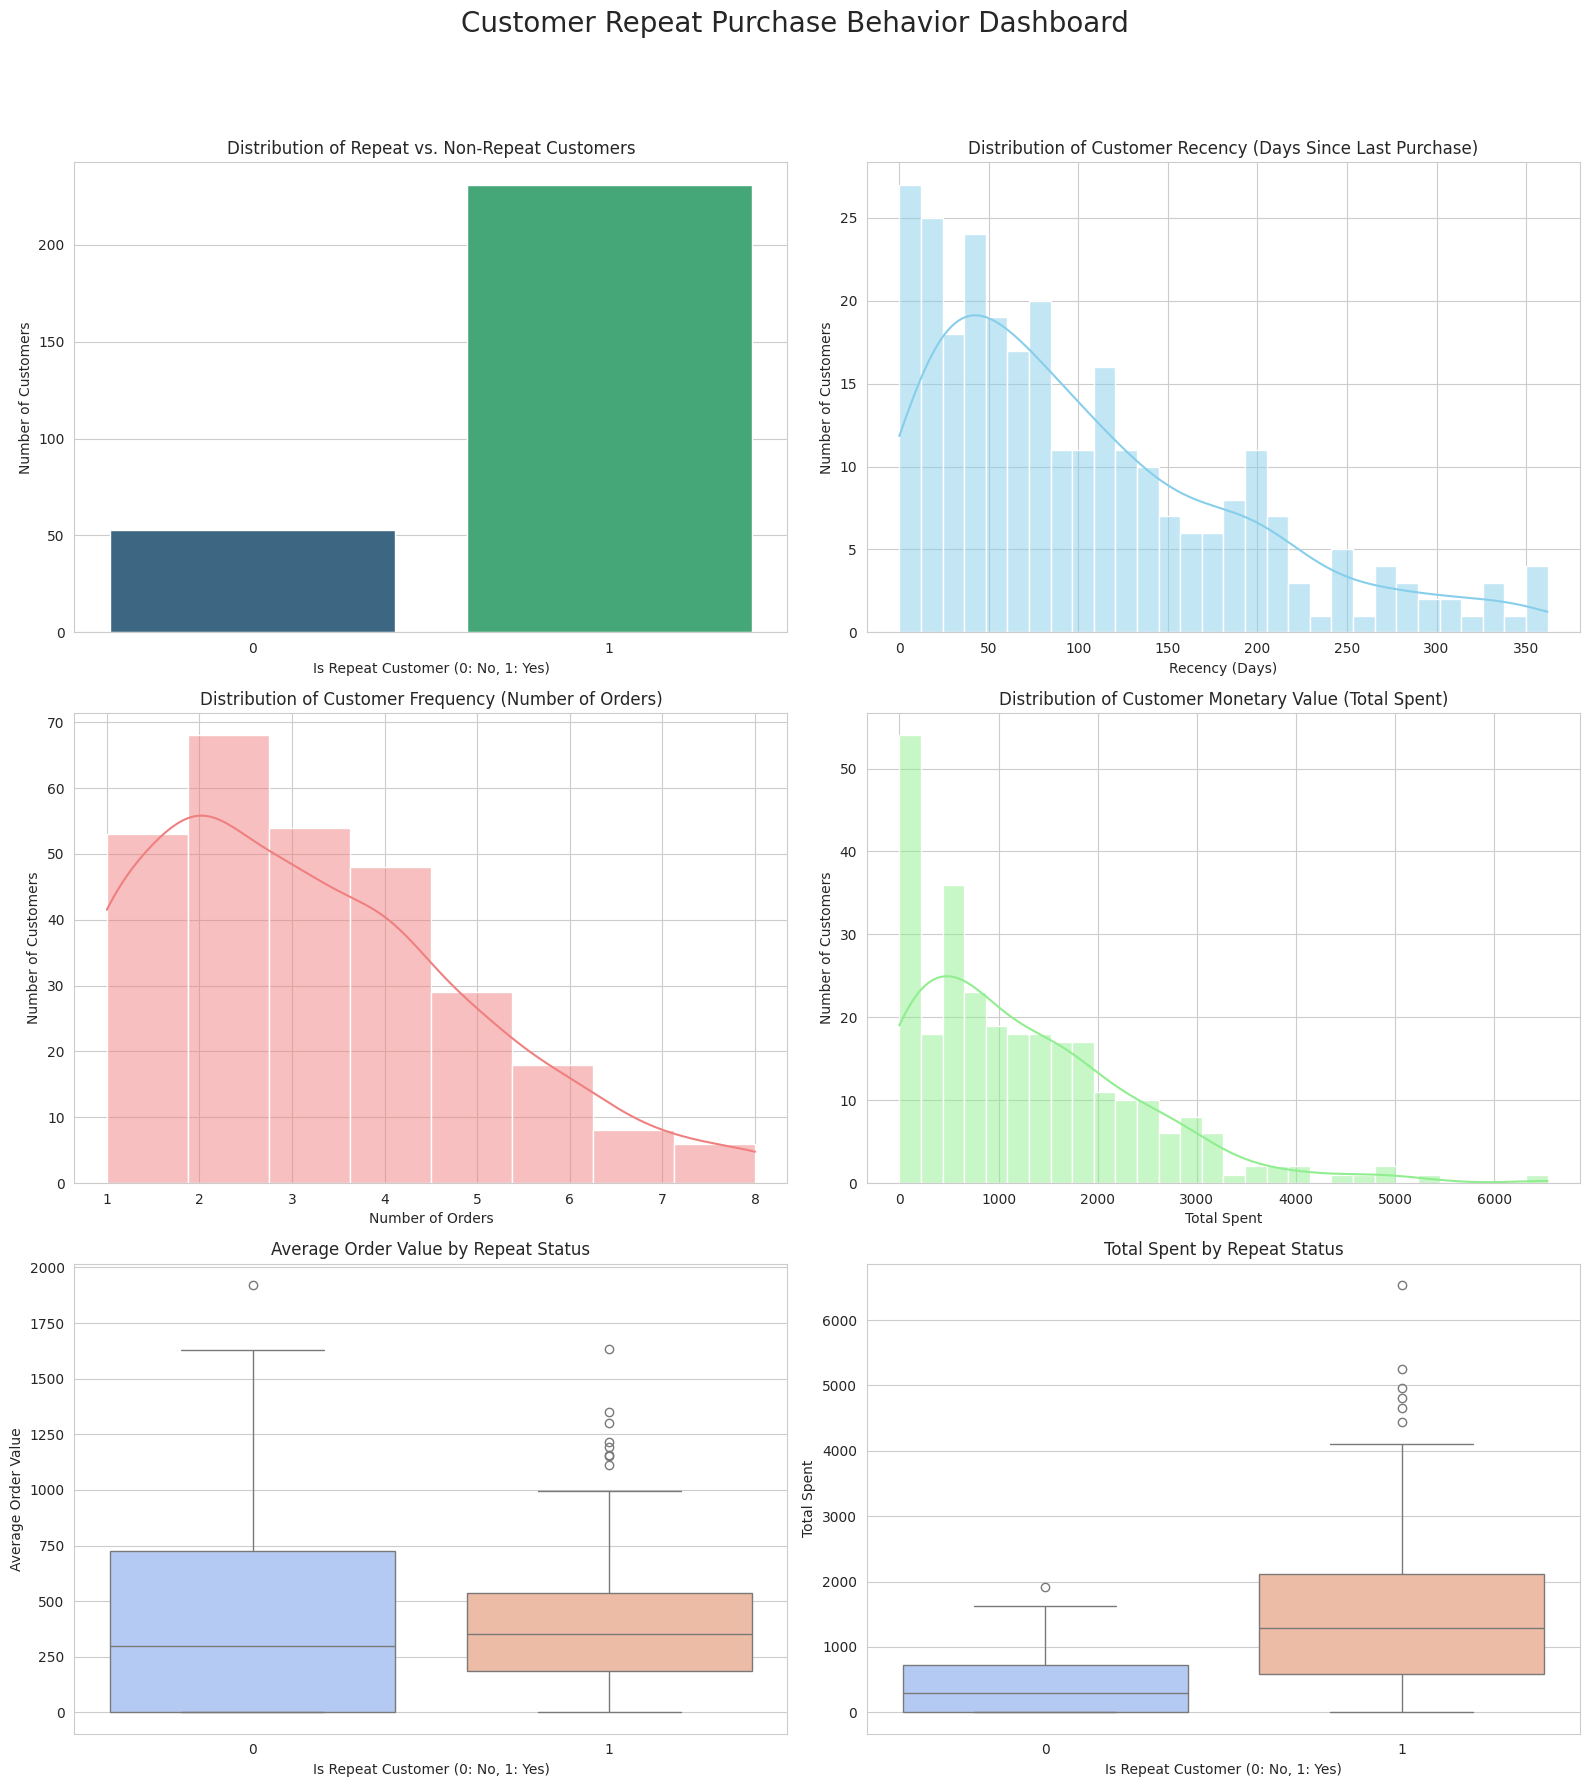

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better aesthetics
sns.set_style("whitegrid")

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(16, 18))
fig.suptitle('Customer Repeat Purchase Behavior Dashboard', fontsize=20, y=1.02)

# 1. Distribution of Repeat Customers
sns.countplot(x='is_repeat_customer', data=rfm_features, ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('Distribution of Repeat vs. Non-Repeat Customers')
axes[0, 0].set_xlabel('Is Repeat Customer (0: No, 1: Yes)')
axes[0, 0].set_ylabel('Number of Customers')

# 2. Distribution of Recency
sns.histplot(rfm_features['recency'], bins=30, kde=True, ax=axes[0, 1], color='skyblue')
axes[0, 1].set_title('Distribution of Customer Recency (Days Since Last Purchase)')
axes[0, 1].set_xlabel('Recency (Days)')
axes[0, 1].set_ylabel('Number of Customers')

# 3. Distribution of Frequency (Number of Orders)
sns.histplot(rfm_features['num_orders'], bins=rfm_features['num_orders'].max(), kde=True, ax=axes[1, 0], color='lightcoral')
axes[1, 0].set_title('Distribution of Customer Frequency (Number of Orders)')
axes[1, 0].set_xlabel('Number of Orders')
axes[1, 0].set_ylabel('Number of Customers')

# 4. Distribution of Monetary (Total Spent)
sns.histplot(rfm_features['total_spent'], bins=30, kde=True, ax=axes[1, 1], color='lightgreen')
axes[1, 1].set_title('Distribution of Customer Monetary Value (Total Spent)')
axes[1, 1].set_xlabel('Total Spent')
axes[1, 1].set_ylabel('Number of Customers')

# 5. Average Order Value by Repeat Status
sns.boxplot(x='is_repeat_customer', y='avg_order_value', data=rfm_features, ax=axes[2, 0], palette='coolwarm')
axes[2, 0].set_title('Average Order Value by Repeat Status')
axes[2, 0].set_xlabel('Is Repeat Customer (0: No, 1: Yes)')
axes[2, 0].set_ylabel('Average Order Value')

# 6. Total Spent by Repeat Status
sns.boxplot(x='is_repeat_customer', y='total_spent', data=rfm_features, ax=axes[2, 1], palette='coolwarm')
axes[2, 1].set_title('Total Spent by Repeat Status')
axes[2, 1].set_xlabel('Is Repeat Customer (0: No, 1: Yes)')
axes[2, 1].set_ylabel('Total Spent')

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent overlap
plt.show()
